# SUPPORT VECTOR MACHINE (SVM) 
**To classify the mobile phone as budget or premium phone (Manual Calculation)**

In [1]:
# Input given
RAM = 6
Price = 28

w1 = 2
w2 = 0.5
b=-20


# Decision Formula
#print("Decision = (w1*x1) + (w2*x2)+b")
decision = (w1*RAM) + (w2*Price) + b
print("Decision:",decision)

# Make Prediction
if decision > 0:
    y = 1
    print("prediction = +1")
    print("Phone Type: Premium")
else:
    y = 0
    print("prediction = -1")
    print("Phone Type: Budget")

# Margin Calculation
y = 1
#print("y ((w1*x1) + (w2*x2)+b)") 
margin = y * decision
print("Margin:",margin)

# Check the margin
if margin >= 1:
    print("Margin >= 1")
    print("Correctly classified!")
    print("Point is outside the margin")
else:
    print("Margin <= 1")
    print("Point is inside the margin or incorrectly classified")

# check the decision boundary
#print("w1*x1 + w2*x2 + b = 0")
print(w1,"* RAM +",w2,"* Price +",b,"= 0")

# Final Summary
print("\n========================================")
print("              SVM SUMMARY")
print("========================================")

print("RAM                  :", RAM, "GB")
print("Price                :", Price, "₹ Thousand")
print("Decision Value       :", decision)
print("Prediction           :", "Premium" if decision > 0 else "Budget")
print("Margin               :", margin)
print("Correctly Classified :", "YES" if margin >= 1 else "NO")

print("\nKey Formula:")
print("Decision = w1*x1 + w2*x2 + b")

print("\nMargin Formula:")
print("Margin = y * (w1*x1 + w2*x2 + b)")

print("\nDecision Boundary:")
print("w1*x1 + w2*x2 + b = 0")

Decision: 6.0
prediction = +1
Phone Type: Premium
Margin: 6.0
Margin >= 1
Correctly classified!
Point is outside the margin
2 * RAM + 0.5 * Price + -20 = 0

              SVM SUMMARY
RAM                  : 6 GB
Price                : 28 ₹ Thousand
Decision Value       : 6.0
Prediction           : Premium
Margin               : 6.0
Correctly Classified : YES

Key Formula:
Decision = w1*x1 + w2*x2 + b

Margin Formula:
Margin = y * (w1*x1 + w2*x2 + b)

Decision Boundary:
w1*x1 + w2*x2 + b = 0


## Problem Statement: Mobile Phone Classification
**Dataset given: Mobile_phones.csv**

In [2]:
# Import the libraries
import numpy as np
import pandas as pd

In [3]:
# Load the dataset and convert to DataFrame using pandas 
df = pd.read_csv("mobile_phones.csv")
print(df.head())

   ram_gb  price_thousand  target
0       4            21.1       1
1       7            27.6       0
2      14            73.0       1
3       4             8.0       0
4       5            25.1       1


In [4]:
# Select features(Input) and Target(Output) 
X = df[["ram_gb","price_thousand"]].values
y = df["target"].values
print("X:")
print(X)
print("Original y:")
print(y)

X:
[[ 4.  21.1]
 [ 7.  27.6]
 [14.  73. ]
 ...
 [16.  75. ]
 [ 3.  30.1]
 [14.  56.5]]
Original y:
[1 0 1 0 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 0 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1
 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 0 0 0 1 1 0 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 1 1 1
 0 1 1 1 0 1 0 1 1 0 1 0 0 0 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 1 0 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0
 1 0 1 1 1 1 1 1 0 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 0 1 0 1
 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 

In [5]:
#convert taget for svm
y = np.where(y == 0, -1, 1)
print("Converted y:")
print(y)

Converted y:
[ 1 -1  1 -1  1  1 -1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1 -1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1 -1  1  1 -1  1  1  1  1  1 -1 -1  1  1  1  1  1  1 -1  1  1 -1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1 -1  1  1  1  1  1 -1  1  1  1  1  1 -1 -1  1  1  1  1  1
  1  1  1  1  1  1 -1  1  1 -1  1  1  1  1  1 -1 -1 -1  1  1 -1 -1  1  1
  1  1 -1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1 -1  1
  1  1  1  1  1  1 -1  1  1  1  1 -1 -1  1  1  1  1 -1  1  1  1 -1  1 -1
  1  1 -1  1 -1 -1 -1  1 -1  1 -1  1  1  1  1 -1  1  1  1  1  1  1  1  1
  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1 -1  1  1  1  1  1 -1  1 -1 -1  1  1  1  1  1  1  1 -1  1  1  1  1  1
  1  1  1 -1 -1  1  1 -1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1 -1  1  1  1  1  1 -1  1 -1  1  1  1  1  1  1 -1  1  1  1 -1 -1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  

In [6]:
# Feature Scaling
X_mean = X.mean(axis = 0)
X_std = X.std(axis = 0)
X_scaled = (X - X_mean) / X_std
print("Mean:")
print(X_mean)
print("Standard Deviation:")
print(X_std)
print("Scaled X:")
print(X_scaled)

Mean:
[ 9.038  44.0611]
Standard Deviation:
[ 4.31538596 18.78899669]
Scaled X:
[[-1.16745062 -1.22205035]
 [-0.47226367 -0.87610319]
 [ 1.14983921  1.54020465]
 ...
 [ 1.61329718  1.64664993]
 [-1.3991796  -0.74304659]
 [ 1.14983921  0.66203109]]


In [7]:
# Initialize SVM Parameters
w1 = 0.0
w2 = 0.0
b = 0.0
learning_rate = 0.001
C = 1 

In [8]:
#Starting SVM training
epochs = 1000
for epoch in range(epochs):
    for i in range(len(X_scaled)):
        # Get Scaled features
        x1 = X_scaled[i][0]
        x2 = X_scaled[i][1]
        
        # Calculate decision
        decision = w1 * x1 + w2 * x2 + b
        
        # Calculate margin
        margin = y[i] * decision
        
        # Check the margin
        if margin >= 1:
            # Correctly classified
            w1 = w1 
            w2 = w2 
        else:
            w1 = w1 + learning_rate * (X[i][0] * y[i])
            w2 = w2 + learning_rate * (X[i][1] * y[i])
            
            #update bias
            b = b + learning_rate * y[i]

    # Display learning process
    if (epoch + 1) % 100 == 0:
        print("epoch",epoch +1,"| w1 =", round(w1, 4),"| w2 =", round(w2, 4),"| b =", round(b, 4))

epoch 100 | w1 = 188.612 | w2 = 1067.0054 | b = 33.658
epoch 200 | w1 = 375.812 | w2 = 2126.6354 | b = 67.158
epoch 300 | w1 = 563.012 | w2 = 3186.2654 | b = 100.658
epoch 400 | w1 = 750.212 | w2 = 4245.8954 | b = 134.158
epoch 500 | w1 = 937.412 | w2 = 5305.5254 | b = 167.658
epoch 600 | w1 = 1124.612 | w2 = 6365.1554 | b = 201.158
epoch 700 | w1 = 1311.812 | w2 = 7424.7854 | b = 234.658
epoch 800 | w1 = 1499.012 | w2 = 8484.4154 | b = 268.158
epoch 900 | w1 = 1686.212 | w2 = 9544.0454 | b = 301.658
epoch 1000 | w1 = 1873.412 | w2 = 10603.6754 | b = 335.158


In [9]:
# Training Completed
print("Learned w1 =", round(w1, 4))
print("Learned w2 =", round(w2, 4))
print("Learned b  =", round(b, 4))

Learned w1 = 1873.412
Learned w2 = 10603.6754
Learned b  = 335.158


In [10]:
# Test the training data
predictions = []
for i in range(len(X_scaled)):
    x1 = X_scaled[i][0]
    x2 = X_scaled[i][1]

    decision = w1 * x1 + w2 * x2 + b

    if decision >= 0:
        prediction = 1       # Premium
    else:
        prediction = -1      # Budget
        
    predictions.append(prediction)

predictions = np.array(predictions)

In [11]:
# Test Accuracy
correct = np.sum(predictions == y)
total = len(y)
accuracy = correct / total

print("Correct predictions:", correct)
print("Total records:", total)
print("Accuracy:", round(accuracy * 100, 2), "%")

Correct predictions: 665
Total records: 1000
Accuracy: 66.5 %


In [12]:
# Test a new phone
new_ram = 10
new_price = 50
print("RAM   :", new_ram, "GB")
print("Price : ₹", new_price, "thousand")

# Scale the new phone
new_x1 = (new_ram - X_mean[0]) / X_std[0]
new_x2 = (new_price - X_mean[1]) / X_std[1]
print("\nScaled values:")
print("x1 =", round(new_x1, 4))
print("x2 =", round(new_x2, 4))

# calculate the Decision
decision = (w1 * new_x1 + w2 * new_x2 + b)
print("\nDecision:",round(decision,4))

# Final Prediction
if decision >= 0:
    print("\nPrediction: PREMIUM PHONE")
else:
    print("\nPrediction: BUDGET PHONE")

RAM   : 10 GB
Price : ₹ 50 thousand

Scaled values:
x1 = 0.2229
x2 = 0.3161

Decision: 4104.4366

Prediction: PREMIUM PHONE


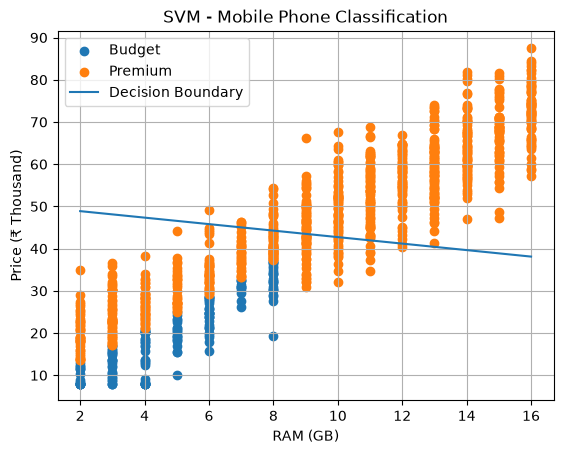

In [13]:
# Data Visualization
import matplotlib.pyplot as plt

# Separate Budget and Premium phones
budget = df[df["target"] == 0]
premium = df[df["target"] == 1]

# Plot Budget phones
plt.scatter(
    budget["ram_gb"],
    budget["price_thousand"],
    label="Budget"
)

# Plot Premium phones
plt.scatter(
    premium["ram_gb"],
    premium["price_thousand"],
    label="Premium"
)

# Create decision boundary
ram_values = np.linspace(
    df["ram_gb"].min(),
    df["ram_gb"].max(),
    100
)

# Scale RAM values
ram_scaled = (ram_values - X_mean[0]) / X_std[0]

# From:
# w1*x1 + w2*x2 + b = 0
#
# x2 = -(w1*x1 + b) / w2

price_scaled = -(w1 * ram_scaled + b) / w2

# Convert scaled price back to original price
price_values = (
    price_scaled * X_std[1]
    + X_mean[1]
)

# Plot decision boundary
plt.plot(
    ram_values,
    price_values,
    label="Decision Boundary"
)

plt.xlabel("RAM (GB)")
plt.ylabel("Price (₹ Thousand)")
plt.title("SVM - Mobile Phone Classification")

plt.legend()
plt.grid(True)

plt.show()